# Module 2: Merged Normalized Data Analysis

This notebook analyzes the normalized merged training data before sequence generation.

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('✓ Libraries loaded')

✓ Libraries loaded


## Load Data

In [3]:
possible_paths = [
    Path('./data/merged/training_data_normalized_merged.csv'),
    Path('../data/merged/training_data_normalized_merged.csv'),
    Path('/tmp/training_data_normalized_merged.csv'),
]

csv_path = None
for p in possible_paths:
    if p.exists():
        csv_path = p
        print(f'✓ Found CSV at: {csv_path}')
        break

if csv_path:
    df = pd.read_csv(csv_path)
    print(f'✓ Loaded {len(df):,} rows, {len(df.columns)} columns')
else:
    print('✗ CSV not found')

✓ Found CSV at: data\merged\training_data_normalized_merged.csv
✓ Loaded 533,338 rows, 11 columns


## Data Overview

In [4]:
print('='*80)
print('DATA STRUCTURE')
print('='*80)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print('\nFirst 3 rows:')
df.head(3)

DATA STRUCTURE
Shape: (533338, 11)
Columns: ['timestamp', 'case_source', 'cmdb_id', 'new_container_id', 'container_cpu_usage_seconds_total', 'container_cpu_system_seconds_total', 'container_cpu_user_seconds_total', 'container_memory_usage_bytes', 'container_memory_working_set_bytes', 'container_memory_rss', 'container_memory_cache']

First 3 rows:


,timestamp,case_source,cmdb_id,new_container_id,container_cpu_usage_seconds_total,container_cpu_system_seconds_total,container_cpu_user_seconds_total,container_memory_usage_bytes,container_memory_working_set_bytes,container_memory_rss,container_memory_cache
0,1719223200,complex_case2,observe.cartservice-0,container_1,0.019471,0.224150,-0.085150,1.781805,1.937829,1.122773,1.937149
1,1719223200,complex_case2,observe.cartservice-1,container_2,0.018900,0.228312,-0.070982,3.262130,3.281267,1.218639,4.143833
2,1719223200,complex_case2,observe.cartservice-2,container_3,0.022336,0.198929,-0.095883,1.603348,1.692764,1.208077,1.620692


## Timestamp Analysis

In [5]:
import datetime

ts_min = int(df['timestamp'].min())
ts_max = int(df['timestamp'].max())

dt_min = datetime.datetime.fromtimestamp(ts_min, tz=datetime.timezone.utc)
dt_max = datetime.datetime.fromtimestamp(ts_max, tz=datetime.timezone.utc)

print('='*80)
print('TIMESTAMP ANALYSIS')
print('='*80)
print(f'Start: {ts_min} → {dt_min.strftime("%Y-%m-%d %H:%M:%S UTC")}')
print(f'End: {ts_max} → {dt_max.strftime("%Y-%m-%d %H:%M:%S UTC")}')

duration = (ts_max - ts_min) / (24 * 3600)
print(f'Duration: {duration:.2f} days')
print(f'✓ Timestamps are continuous' if df['timestamp'].diff().unique()[1:].size == 1 else '⚠ Non-uniform intervals')

TIMESTAMP ANALYSIS
Start: 1719223200 → 2024-06-24 10:00:00 UTC
End: 1719446205 → 2024-06-26 23:56:45 UTC
Duration: 2.58 days
⚠ Non-uniform intervals


## Case Distribution

Rows per case:
  complex_case1  : 318,445 ( 59.7%)
  complex_case2  :  94,932 ( 17.8%)
  single_case1   :  74,223 ( 13.9%)
  single_case2   :  45,738 (  8.6%)


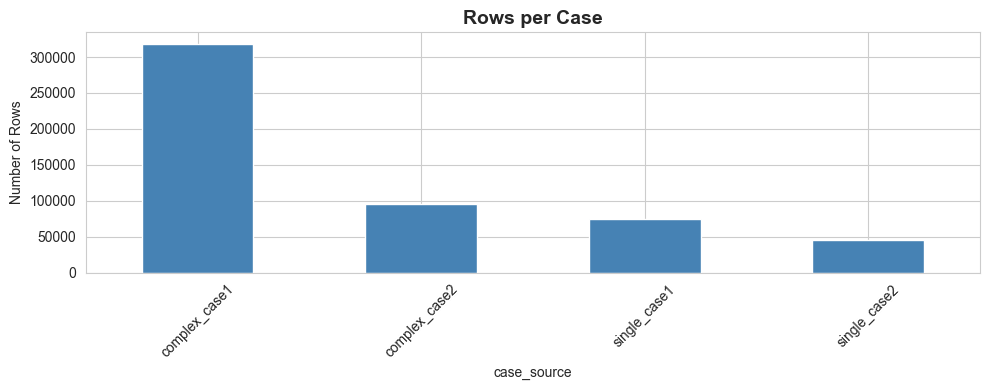

In [6]:
case_counts = df['case_source'].value_counts().sort_index()
print('Rows per case:')
for case, count in case_counts.items():
    pct = (count / len(df)) * 100
    print(f'  {case:15s}: {count:7,d} ({pct:5.1f}%)')

fig, ax = plt.subplots(figsize=(10, 4))
case_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Rows per Case', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Rows')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Data Quality

In [7]:
print('='*80)
print('DATA QUALITY CHECK')
print('='*80)
print(f'Null values: {df.isnull().sum().sum()}')
print(f'✓ No null values' if df.isnull().sum().sum() == 0 else '✗ Found nulls')
print(f'Unique containers: {df["new_container_id"].nunique()}')
print(f'Duplicate rows: {df.duplicated().sum()}')

DATA QUALITY CHECK
Null values: 0
✓ No null values
Unique containers: 27
Duplicate rows: 96204


## Metrics Statistics

In [8]:
metrics = [
    'container_cpu_usage_seconds_total',
    'container_memory_usage_bytes',
]

print('Normalized Metrics Statistics:')
print(f'{"Metric":<40s} {"Mean":>10s} {"Std":>10s} {"Min":>10s} {"Max":>10s}')
print('-'*80)

for metric in metrics:
    mean = df[metric].mean()
    std = df[metric].std()
    min_val = df[metric].min()
    max_val = df[metric].max()
    print(f'{metric:<40s} {mean:10.4f} {std:10.4f} {min_val:10.4f} {max_val:10.4f}')

Normalized Metrics Statistics:
Metric                                         Mean        Std        Min        Max
--------------------------------------------------------------------------------
container_cpu_usage_seconds_total           -0.0000     1.0000    -1.0114     4.4310
container_memory_usage_bytes                 0.0000     1.0000    -4.1881     6.7046


## Time Series Plot

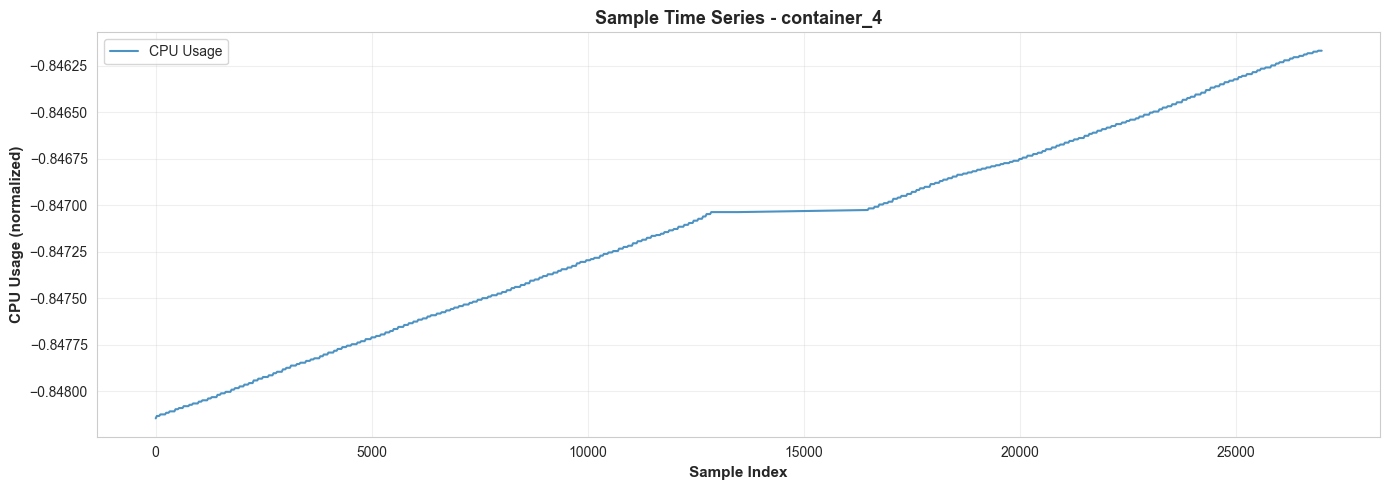

In [9]:
sample_container = df['new_container_id'].iloc[3]
sample_data = df[df['new_container_id'] == sample_container].sort_values('timestamp').head(1000)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample_data['container_cpu_usage_seconds_total'], label='CPU Usage', linewidth=1.5, alpha=0.8)
ax.set_ylabel('CPU Usage (normalized)', fontsize=11, fontweight='bold')
ax.set_xlabel('Sample Index', fontsize=11, fontweight='bold')
ax.set_title(f'Sample Time Series - {sample_container}', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Summary

In [10]:
print('='*80)
print('DATA READINESS SUMMARY')
print('='*80)
print(f'✓ Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'✓ Null values: {df.isnull().sum().sum()}')
print(f'✓ Unique containers: {df["new_container_id"].nunique()}')
print(f'✓ Cases: {df["case_source"].nunique()}')
print(f'✓ Normalization: Per-case z-score applied')
print(f'\n✓ DATA IS READY FOR SEQUENCE GENERATION')

DATA READINESS SUMMARY
✓ Shape: 533,338 rows × 11 columns
✓ Null values: 0
✓ Unique containers: 27
✓ Cases: 4
✓ Normalization: Per-case z-score applied

✓ DATA IS READY FOR SEQUENCE GENERATION
